In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import yfinance as yf

In [2]:
data = yf.download(tickers="^SPX", period="max")
data = data["Close"]

C:\Users\bump1\AppData\Local\Temp\ipykernel_55000\1596001764.py:1: FutureWarning: YF.download() has changed argument auto_adjust default to True
  data = yf.download(tickers="^SPX", period="max")
[*********************100%***********************]  1 of 1 completed


In [3]:
price = np.array(data)
daily_return = price[1:]/price[:-1] -1
print(np.std(daily_return)*np.sqrt(250))


0.18853682723603285


In [5]:
from src import BullSpreadClass
cppi = BullSpreadClass.SingleAssetCPPI(data, "2000/1/4", "2025/10/15")
obpi = BullSpreadClass.SingleAssetOBPI(data, "2000/1/4", "2025/10/15")
bull_spread = BullSpreadClass.SingleAssetBullSpread(data, "2000/1/4", "2025/10/15")


(24683, 1)
18079 24563 6484


c:\Users\bump1\MyFolder\strategy\BullSpreadStrategy\src\BullSpreadClass.py:17: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  self.raw = 10000 * data[self.start_idx:self.end_idx+1].values.T[0] / data.loc[start_date][0]
c:\Users\bump1\MyFolder\strategy\BullSpreadStrategy\src\BullSpreadClass.py:92: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  self.raw = 10000 * data[self.start_idx:self.end_idx+1].values.T[0] / data.loc[start_date][0]
c:\Users\bump1\MyFolder\strategy\BullSpreadStrategy\src\BullSpreadClass.py:170: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer key

In [6]:
c_price, c_volatility, c_floor, c_ratio, c_raw = cppi.run(DEPTH=0.20, PARAM=1, vol_method="exp")
o_price, o_volatility, o_floor, o_ratio, o_raw = obpi.run(DEPTH=0.20, PARAM=1, vol_method="exp")
b_price, b_volatility, b_floor, b_ratio, b_raw, lower_delta, upper_delta, lower_premium, upper_premium = bull_spread.run(FLOORDEPTH=0.20, CAPDEPTH=0.20, PARAM=1, vol_method="exp", strategy='integration')
inv_price, inv_volatility, inv_floor, inv_ratio, inv_raw, inv_delta, inv_premium = bull_spread.run(FLOORDEPTH=0.20, CAPDEPTH=0.20, PARAM=1, vol_method="exp", strategy='point_change')


In [7]:
print(BullSpreadClass.get_performance(c_price))
print(BullSpreadClass.get_performance(o_price))
print(BullSpreadClass.get_performance(b_price))

(np.float64(0.05226421112177316), np.float64(0.11111003194804617), np.float64(0.4703824686704377), np.float64(0.18216460914253474))
(np.float64(0.05011806535369938), np.float64(0.13300155743847075), np.float64(0.3768231464273268), np.float64(0.20400268522575993))
(np.float64(0.05604718227510628), np.float64(0.12925867561577822), np.float64(0.43360480066890583), np.float64(0.2645896880575809))


Text(0.5, 1.0, 'premium')

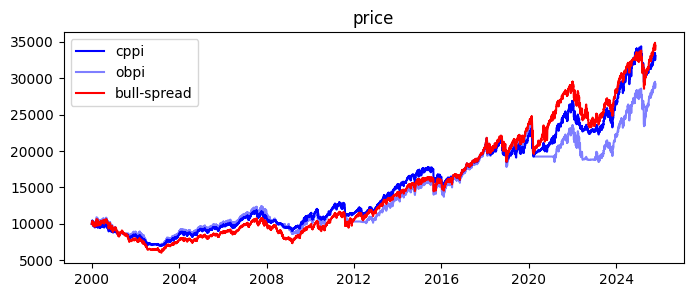

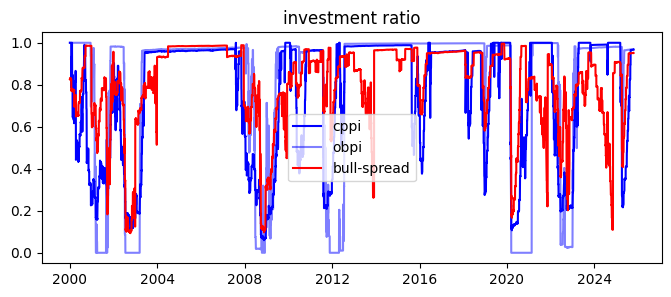

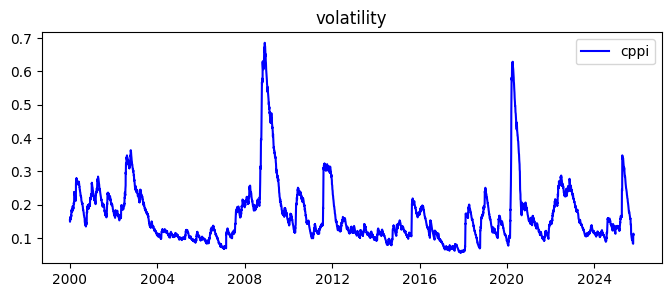

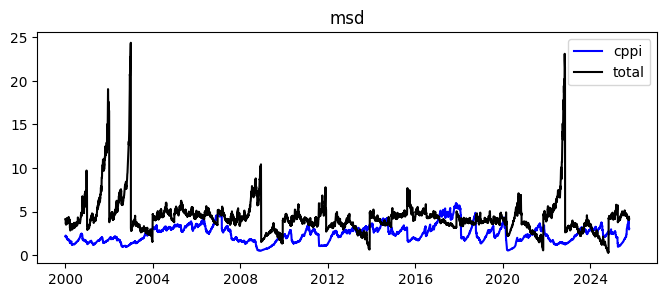

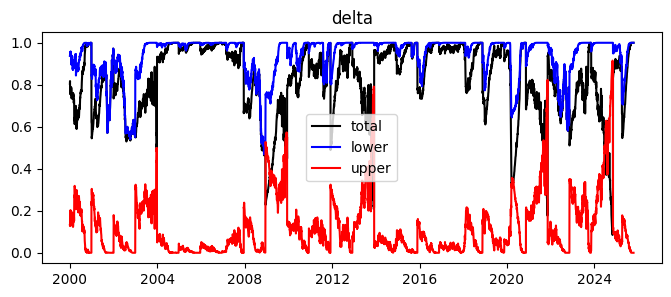

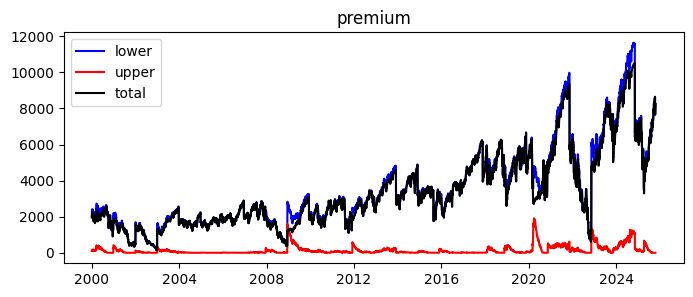

In [8]:
days = cppi.date

plt.figure(figsize=(8,3))
# plt.plot(days, c_raw, label='raw', color="gray")
plt.plot(days, c_price, label='cppi', color="blue")
plt.plot(days, o_price, label='obpi', color="blue", alpha=0.5)
plt.plot(days, b_price, label='bull-spread', color="red")
# plt.plot(days, inv_price, label='bull-spread(inv)', color="red", alpha=0.5)
# plt.plot(days, c_floor, label='floor', color="black")
# plt.plot(days, c_floor/(1-0.15), label='M', color="black")
plt.legend()
plt.title("price")

plt.figure(figsize=(8,3))
plt.plot(days, c_ratio, label='cppi', color="blue")
plt.plot(days, o_ratio, label='obpi', color="blue", alpha=0.5)
plt.plot(days, b_ratio, label='bull-spread', color="red")
# plt.plot(days, inv_ratio, label='bull-spread(inv)', color="red", alpha=0.5)
plt.legend()
plt.title("investment ratio")

plt.figure(figsize=(8,3))
plt.plot(days, c_volatility, label='cppi', color="blue")
plt.legend()
plt.title("volatility")

plt.figure(figsize=(8,3))
plt.plot(days, 1/(3*c_volatility), label='cppi', color="blue")
# plt.plot(days, lower_delta, label="lower", color="blue")
# plt.plot(days, upper_delta, label="upper", color="red")
plt.plot(days, b_price*(lower_delta - upper_delta)/(lower_premium - upper_premium), label="total", color="black")
plt.legend()
plt.title("msd")

plt.figure(figsize=(8,3))
plt.plot(days, lower_delta - upper_delta, label="total", color="black")
plt.plot(days, lower_delta, label="lower", color="blue")
plt.plot(days, upper_delta, label="upper", color="red")
plt.legend()
plt.title("delta")

plt.figure(figsize=(8,3))
plt.plot(days, lower_premium, label="lower", color="blue")
plt.plot(days, upper_premium, label="upper", color="red")
plt.plot(days, lower_premium - upper_premium, label="total", color="black")
plt.legend()
plt.title("premium")